## Training model's on first dataset

In [64]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

import joblib

In [65]:
df = pd.read_csv("construction_estimates (1).csv")

### 1) Data processing

In [66]:
df.head()

,Material_Cost,Labor_Cost,Profit_Rate,Discount_or_Markup,Policy_Reason,Total_Estimate
0,43985,12836,10,1095,Market conditions require competitive pricing ...,63598.10
1,45504,17873,15,-6426,Market conditions require competitive pricing ...,66457.55
2,33656,8401,25,9862,"The client is a repeat customer, deserving a l...",62433.25
3,36509,8523,20,8096,"The client is a repeat customer, deserving a l...",62134.40
4,37372,14123,30,-9598,Strategic importance of this client justifies ...,57345.50


In [67]:
df.shape

(1000, 6)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Material_Cost       1000 non-null   int64  
 1   Labor_Cost          1000 non-null   int64  
 2   Profit_Rate         1000 non-null   int64  
 3   Discount_or_Markup  1000 non-null   int64  
 4   Policy_Reason       1000 non-null   object 
 5   Total_Estimate      1000 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 47.0+ KB


In [69]:
df.describe()

,Material_Cost,Labor_Cost,Profit_Rate,Discount_or_Markup,Total_Estimate
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,29908.74700,17566.307000,19.740000,-73.475000,56769.692700
std,11200.10159,7225.096808,6.955629,5750.120642,17465.481663
min,10038.00000,5067.000000,10.000000,-9987.000000,13319.150000
25%,20528.00000,11462.500000,15.000000,-5102.250000,44069.300000
50%,30023.50000,17591.500000,20.000000,-131.000000,57121.350000
75%,39438.75000,23738.750000,25.000000,4980.000000,69295.100000
max,49947.00000,29923.000000,30.000000,9979.000000,109165.400000


In [70]:
df.isnull().sum()

Material_Cost         0
Labor_Cost            0
Profit_Rate           0
Discount_or_Markup    0
Policy_Reason         0
Total_Estimate        0
dtype: int64

In [71]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [72]:
# Check unique values in categorical column
df["Policy_Reason"].unique()

array(['Market conditions require competitive pricing for this project.',
       'The client is a repeat customer, deserving a loyalty discount.',
       'Strategic importance of this client justifies special pricing.',
       'This project includes additional risks, necessitating higher markup.',
       'This client is new but has potential for growth.'], dtype=object)

In [73]:
# Convert categorical column to numeric
df = pd.get_dummies(df, columns=["Policy_Reason"], drop_first=True)

In [74]:
df.columns

Index(['Material_Cost', 'Labor_Cost', 'Profit_Rate', 'Discount_or_Markup',
       'Total_Estimate',
       'Policy_Reason_Strategic importance of this client justifies special pricing.',
       'Policy_Reason_The client is a repeat customer, deserving a loyalty discount.',
       'Policy_Reason_This client is new but has potential for growth.',
       'Policy_Reason_This project includes additional risks, necessitating higher markup.'],
      dtype='object')

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                                                                              Non-Null Count  Dtype  
---  ------                                                                              --------------  -----  
 0   Material_Cost                                                                       1000 non-null   int64  
 1   Labor_Cost                                                                          1000 non-null   int64  
 2   Profit_Rate                                                                         1000 non-null   int64  
 3   Discount_or_Markup                                                                  1000 non-null   int64  
 4   Total_Estimate                                                                      1000 non-null   float64
 5   Policy_Reason_Strategic importance of this client justifies special pricing.        1000 non-null  

### 2)EDA (Exploratory Data Analysis)

In [76]:
df.describe()

,Material_Cost,Labor_Cost,Profit_Rate,Discount_or_Markup,Total_Estimate
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,29908.74700,17566.307000,19.740000,-73.475000,56769.692700
std,11200.10159,7225.096808,6.955629,5750.120642,17465.481663
min,10038.00000,5067.000000,10.000000,-9987.000000,13319.150000
25%,20528.00000,11462.500000,15.000000,-5102.250000,44069.300000
50%,30023.50000,17591.500000,20.000000,-131.000000,57121.350000
75%,39438.75000,23738.750000,25.000000,4980.000000,69295.100000
max,49947.00000,29923.000000,30.000000,9979.000000,109165.400000


In [77]:
df.corr()

,Material_Cost,Labor_Cost,Profit_Rate,Discount_or_Markup,Total_Estimate,Policy_Reason_Strategic importance of this client justifies special pricing.,"Policy_Reason_The client is a repeat customer, deserving a loyalty discount.",Policy_Reason_This client is new but has potential for growth.,"Policy_Reason_This project includes additional risks, necessitating higher markup."
Material_Cost,1.000000,0.034585,-0.007108,0.052946,0.798886,0.012027,-0.017122,-0.082202,0.037689
Labor_Cost,0.034585,1.000000,0.004123,-0.074474,0.497173,0.020258,0.017682,-0.032925,-0.025514
Profit_Rate,-0.007108,0.004123,1.000000,-0.039975,0.172433,0.047694,-0.020386,-0.005489,-0.031631
Discount_or_Markup,0.052946,-0.074474,-0.039975,1.000000,0.325117,-0.049013,0.025142,-0.013657,-0.050870
Total_Estimate,0.798886,0.497173,0.172433,0.325117,1.000000,0.011116,0.000282,-0.081443,-0.007087
Policy_Reason_Strategic importance of this client justifies special pricing.,0.012027,0.020258,0.047694,-0.049013,0.011116,1.000000,-0.260212,-0.247449,-0.278675
"Policy_Reason_The client is a repeat customer, deserving a loyalty discount.",-0.017122,0.017682,-0.020386,0.025142,0.000282,-0.260212,1.000000,-0.223062,-0.251211
Policy_Reason_This client is new but has potential for growth.,-0.082202,-0.032925,-0.005489,-0.013657,-0.081443,-0.247449,-0.223062,1.000000,-0.238889
"Policy_Reason_This project includes additional risks, necessitating higher markup.",0.037689,-0.025514,-0.031631,-0.050870,-0.007087,-0.278675,-0.251211,-0.238889,1.000000


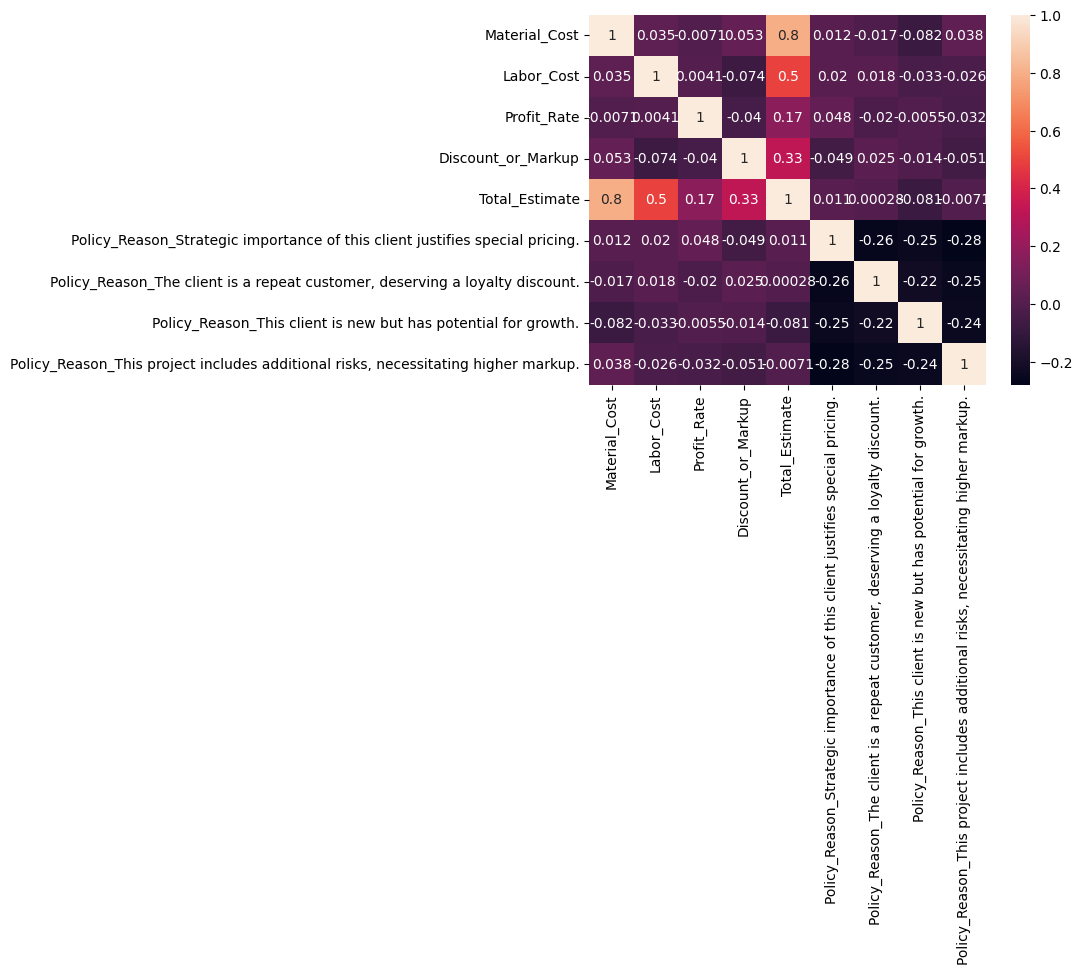

In [78]:
sns.heatmap(df.corr(), annot=True)
plt.show()

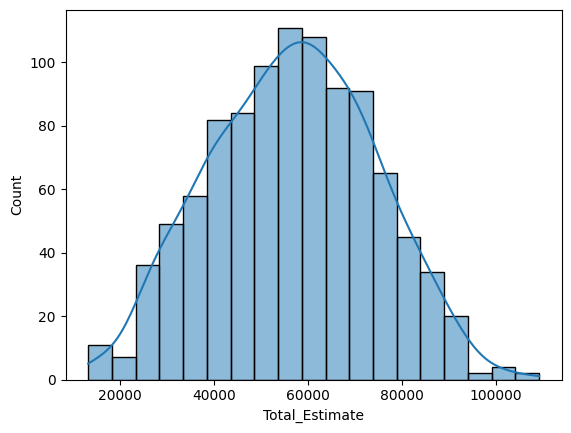

In [79]:
sns.histplot(df["Total_Estimate"], kde=True)
plt.show()

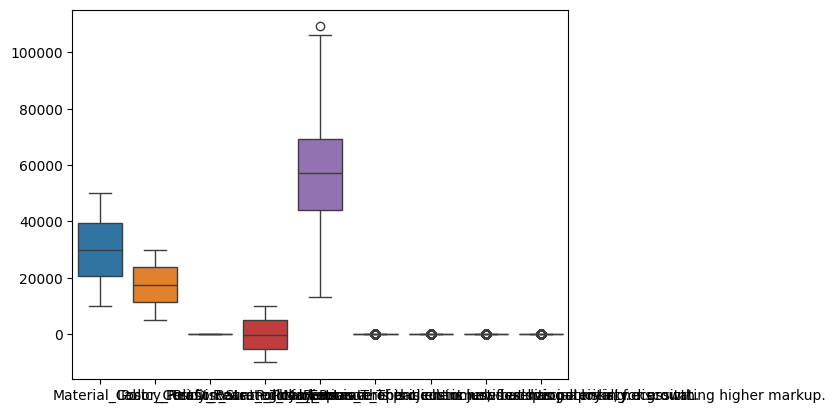

In [80]:
sns.boxplot(data=df)
plt.show()

### 3) Feature Selection / Feature Extraction

In [81]:
# check correlation with target variable
df.corr()["Total_Estimate"].sort_values(ascending=False)

Total_Estimate                                                                        1.000000
Material_Cost                                                                         0.798886
Labor_Cost                                                                            0.497173
Discount_or_Markup                                                                    0.325117
Profit_Rate                                                                           0.172433
Policy_Reason_Strategic importance of this client justifies special pricing.          0.011116
Policy_Reason_The client is a repeat customer, deserving a loyalty discount.          0.000282
Policy_Reason_This project includes additional risks, necessitating higher markup.   -0.007087
Policy_Reason_This client is new but has potential for growth.                       -0.081443
Name: Total_Estimate, dtype: float64

In [82]:
# define input features (X) and target variable (y)

X = df.drop("Total_Estimate", axis=1)
y = df["Total_Estimate"]

In [83]:
# check feature shape
X.shape

(1000, 8)

In [84]:
# check target shape
y.shape

(1000,)

### 4) Scale the Values (Feature Scaling)

In [85]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [86]:
X_scaled.shape

(1000, 8)

### 5)Train Test Split (with Cross Validation)

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [88]:
X_train.shape

(800, 8)

In [89]:
X_test.shape

(200, 8)

### 6) Train the Models

####  a) Linear Regression

In [90]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### b) Random Forest

In [91]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

#### c) Gradient Boosting

In [92]:
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

#### d) XGBoost

In [93]:
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

### 7) Evaluate the Models / Model Selection

In [94]:
# Predictions
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

In [95]:
# Linear Regression metrics
print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2:", r2_score(y_test, lr_pred))

Linear Regression
MAE: 632.3793126235782
RMSE: 931.9661186396522
R2: 0.9969915560299849


In [96]:
# Random Forest metrics
print("Random Forest")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2:", r2_score(y_test, rf_pred))

Random Forest
MAE: 2328.642172499997
RMSE: 2921.7811776694384
R2: 0.9704309716610618


In [97]:
# Gradient Boosting metrics
print("Gradient Boosting")
print("MAE:", mean_absolute_error(y_test, gb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, gb_pred)))
print("R2:", r2_score(y_test, gb_pred))

Gradient Boosting
MAE: 1635.7738897680258
RMSE: 2014.2152016565415
R2: 0.9859475056869622


In [98]:
# XGBoost metrics
print("XGBoost")
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R2:", r2_score(y_test, xgb_pred))

XGBoost
MAE: 1916.4285302734374
RMSE: 2524.984075784434
R2: 0.9779169545368503


## Train the model's on second dataset 

### 1) Data processing

In [99]:
df2 = pd.read_csv("house_price_dataset_india_12k.csv")

In [100]:
df2.head()

,House_ID,City,Locality_Tier,BHK,Bathrooms,Super_Area_sqft,Carpet_Area_sqft,Floor_No,Total_Floors,Property_Age_years,...,Furnishing,Lift,Gated_Society,Distance_to_Metro_km,Distance_to_CityCenter_km,Nearby_School_km,Nearby_Hospital_km,Crime_Rate_Index,Market_Price_INR,Price_per_sqft_INR
0,1,Hyderabad,Mid,3,4,957.3,809.1,11,15,8,...,Semi-Furnished,1,0,2.44,20.76,1.77,3.52,32.4,7736451,8082
1,2,Bangalore,Budget,2,3,883.3,711.7,13,16,13,...,Semi-Furnished,1,0,0.48,17.56,2.82,4.86,66.3,5771877,6534
2,3,Pune,Premium,3,4,1331.5,1087.1,13,15,7,...,Unfurnished,1,1,2.76,9.73,0.20,1.75,23.3,14688106,11031
3,4,Mumbai,Premium,3,4,997.6,801.0,7,19,10,...,Semi-Furnished,1,1,1.12,13.15,0.27,0.61,18.8,19094254,19140
4,5,Pune,Mid,2,2,967.6,707.6,5,16,6,...,Unfurnished,1,1,2.46,14.07,3.34,3.93,41.0,7592420,7847


In [101]:
df2.shape

(12000, 21)

In [52]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   House_ID                   12000 non-null  int64  
 1   City                       12000 non-null  object 
 2   Locality_Tier              12000 non-null  object 
 3   BHK                        12000 non-null  int64  
 4   Bathrooms                  12000 non-null  int64  
 5   Super_Area_sqft            12000 non-null  float64
 6   Carpet_Area_sqft           12000 non-null  float64
 7   Floor_No                   12000 non-null  int64  
 8   Total_Floors               12000 non-null  int64  
 9   Property_Age_years         12000 non-null  int64  
 10  Parking                    12000 non-null  int64  
 11  Furnishing                 12000 non-null  object 
 12  Lift                       12000 non-null  int64  
 13  Gated_Society              12000 non-null  int

In [102]:
df2.describe()

,House_ID,BHK,Bathrooms,Super_Area_sqft,Carpet_Area_sqft,Floor_No,Total_Floors,Property_Age_years,Parking,Lift,Gated_Society,Distance_to_Metro_km,Distance_to_CityCenter_km,Nearby_School_km,Nearby_Hospital_km,Crime_Rate_Index,Market_Price_INR,Price_per_sqft_INR
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,1.200000e+04,12000.000000
mean,6000.50000,2.304167,2.536083,1018.260342,763.563383,7.599000,15.232667,8.615917,0.640083,0.924167,0.588667,2.153820,14.101654,2.807817,3.059477,41.756825,1.020406e+07,9689.409667
std,3464.24595,0.934909,1.102482,379.974189,291.095491,5.685352,5.707604,5.374815,0.479996,0.264742,0.492096,1.817501,7.149948,1.352786,1.507851,13.716940,6.707595e+06,4279.861543
min,1.00000,1.000000,1.000000,350.000000,250.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.200000,0.500000,0.200000,0.300000,5.000000,1.356119e+06,2480.000000
25%,3000.75000,2.000000,2.000000,781.800000,569.700000,3.000000,11.000000,4.000000,0.000000,1.000000,0.000000,0.410000,9.000000,1.840000,1.990000,32.200000,5.586925e+06,6562.750000
50%,6000.50000,2.000000,2.000000,950.500000,715.550000,7.000000,15.000000,8.000000,1.000000,1.000000,1.000000,1.830000,14.010000,2.800000,3.000000,41.800000,8.558740e+06,8763.000000
75%,9000.25000,3.000000,3.000000,1226.300000,915.200000,11.000000,19.000000,12.000000,1.000000,1.000000,1.000000,3.340000,19.000000,3.760000,4.080000,51.400000,1.304248e+07,11980.000000
max,12000.00000,5.000000,7.000000,3010.400000,2285.900000,32.000000,38.000000,33.000000,1.000000,1.000000,1.000000,11.600000,39.800000,8.710000,8.810000,85.400000,5.755283e+07,22626.000000


In [103]:
df2.isnull().sum()

House_ID                     0
City                         0
Locality_Tier                0
BHK                          0
Bathrooms                    0
Super_Area_sqft              0
Carpet_Area_sqft             0
Floor_No                     0
Total_Floors                 0
Property_Age_years           0
Parking                      0
Furnishing                   0
Lift                         0
Gated_Society                0
Distance_to_Metro_km         0
Distance_to_CityCenter_km    0
Nearby_School_km             0
Nearby_Hospital_km           0
Crime_Rate_Index             0
Market_Price_INR             0
Price_per_sqft_INR           0
dtype: int64

In [104]:
# remove identifier column
df2 = df2.drop("House_ID", axis=1)

In [106]:
# check duplicate rows
df2.duplicated().sum()

np.int64(0)

In [107]:
# check unique values in categorical columns
df2["City"].unique()
df2["Locality_Tier"].unique()
df2["Furnishing"].unique()

array(['Semi-Furnished', 'Unfurnished', 'Fully-Furnished'], dtype=object)

In [108]:
# convert categorical columns to numeric
df2 = pd.get_dummies(df2, columns=["City", "Locality_Tier", "Furnishing"], drop_first=True)

In [109]:
# verify dataset after processing
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   BHK                        12000 non-null  int64  
 1   Bathrooms                  12000 non-null  int64  
 2   Super_Area_sqft            12000 non-null  float64
 3   Carpet_Area_sqft           12000 non-null  float64
 4   Floor_No                   12000 non-null  int64  
 5   Total_Floors               12000 non-null  int64  
 6   Property_Age_years         12000 non-null  int64  
 7   Parking                    12000 non-null  int64  
 8   Lift                       12000 non-null  int64  
 9   Gated_Society              12000 non-null  int64  
 10  Distance_to_Metro_km       12000 non-null  float64
 11  Distance_to_CityCenter_km  12000 non-null  float64
 12  Nearby_School_km           12000 non-null  float64
 13  Nearby_Hospital_km         12000 non-null  flo

### 2)EDA (Exploratory Data Analysis)

In [110]:
df2.describe()

,BHK,Bathrooms,Super_Area_sqft,Carpet_Area_sqft,Floor_No,Total_Floors,Property_Age_years,Parking,Lift,Gated_Society,Distance_to_Metro_km,Distance_to_CityCenter_km,Nearby_School_km,Nearby_Hospital_km,Crime_Rate_Index,Market_Price_INR,Price_per_sqft_INR
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,1.200000e+04,12000.000000
mean,2.304167,2.536083,1018.260342,763.563383,7.599000,15.232667,8.615917,0.640083,0.924167,0.588667,2.153820,14.101654,2.807817,3.059477,41.756825,1.020406e+07,9689.409667
std,0.934909,1.102482,379.974189,291.095491,5.685352,5.707604,5.374815,0.479996,0.264742,0.492096,1.817501,7.149948,1.352786,1.507851,13.716940,6.707595e+06,4279.861543
min,1.000000,1.000000,350.000000,250.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.200000,0.500000,0.200000,0.300000,5.000000,1.356119e+06,2480.000000
25%,2.000000,2.000000,781.800000,569.700000,3.000000,11.000000,4.000000,0.000000,1.000000,0.000000,0.410000,9.000000,1.840000,1.990000,32.200000,5.586925e+06,6562.750000
50%,2.000000,2.000000,950.500000,715.550000,7.000000,15.000000,8.000000,1.000000,1.000000,1.000000,1.830000,14.010000,2.800000,3.000000,41.800000,8.558740e+06,8763.000000
75%,3.000000,3.000000,1226.300000,915.200000,11.000000,19.000000,12.000000,1.000000,1.000000,1.000000,3.340000,19.000000,3.760000,4.080000,51.400000,1.304248e+07,11980.000000
max,5.000000,7.000000,3010.400000,2285.900000,32.000000,38.000000,33.000000,1.000000,1.000000,1.000000,11.600000,39.800000,8.710000,8.810000,85.400000,5.755283e+07,22626.000000


In [111]:
df2.corr()

,BHK,Bathrooms,Super_Area_sqft,Carpet_Area_sqft,Floor_No,Total_Floors,Property_Age_years,Parking,Lift,Gated_Society,...,Market_Price_INR,Price_per_sqft_INR,City_Hyderabad,City_Mumbai,City_Nagpur,City_Pune,Locality_Tier_Mid,Locality_Tier_Premium,Furnishing_Semi-Furnished,Furnishing_Unfurnished
BHK,1.000000,0.815460,0.937093,0.914697,-0.004647,-0.003674,-0.076128,0.122701,0.006327,0.122704,...,0.693469,0.225157,-0.010124,-0.004201,0.005645,0.008709,-0.015294,0.291996,0.008396,-0.050453
Bathrooms,0.815460,1.000000,0.767007,0.747873,-0.009751,-0.005427,-0.058623,0.095964,0.006235,0.096794,...,0.576934,0.195508,-0.003203,-0.002996,0.007071,0.003363,-0.017995,0.242162,0.013355,-0.053682
Super_Area_sqft,0.937093,0.767007,1.000000,0.976795,-0.003604,-0.000492,-0.071976,0.116282,0.006590,0.112127,...,0.723853,0.207688,-0.006621,-0.003985,0.000383,0.012491,-0.017734,0.278354,0.014377,-0.053692
Carpet_Area_sqft,0.914697,0.747873,0.976795,1.000000,-0.000174,0.000421,-0.065990,0.113576,0.004390,0.107974,...,0.705184,0.200372,-0.004993,-0.005786,-0.000571,0.011138,-0.020524,0.271894,0.012454,-0.050852
Floor_No,-0.004647,-0.009751,-0.003604,-0.000174,1.000000,0.504508,0.002909,0.000949,0.105374,0.005650,...,0.108962,0.165892,-0.054482,0.133787,-0.182446,-0.066246,0.004666,0.001743,0.006044,-0.011726
Total_Floors,-0.003674,-0.005427,-0.000492,0.000421,0.504508,1.000000,0.004247,0.010674,0.194403,0.015977,...,0.222253,0.337679,-0.114647,0.276554,-0.372194,-0.115228,-0.007088,0.014374,0.009087,-0.010686
Property_Age_years,-0.076128,-0.058623,-0.071976,-0.065990,0.002909,0.004247,1.000000,-0.066961,-0.009870,-0.053908,...,-0.112751,-0.114489,-0.001536,0.008177,-0.004524,0.001939,-0.003748,-0.166297,0.003014,0.021576
Parking,0.122701,0.095964,0.116282,0.113576,0.000949,0.010674,-0.066961,1.000000,0.002280,0.115182,...,0.180189,0.186149,-0.000535,-0.003226,-0.012117,0.010187,0.013814,0.262888,0.027802,-0.054740
Lift,0.006327,0.006235,0.006590,0.004390,0.105374,0.194403,-0.009870,0.002280,1.000000,0.014513,...,0.062801,0.088305,-0.004827,0.050394,-0.104214,-0.003950,0.001859,0.014008,0.008514,-0.008686
Gated_Society,0.122704,0.096794,0.112127,0.107974,0.005650,0.015977,-0.053908,0.115182,0.014513,1.000000,...,0.178579,0.183647,0.017339,0.014007,-0.011719,-0.023235,0.013174,0.249981,0.011078,-0.042283


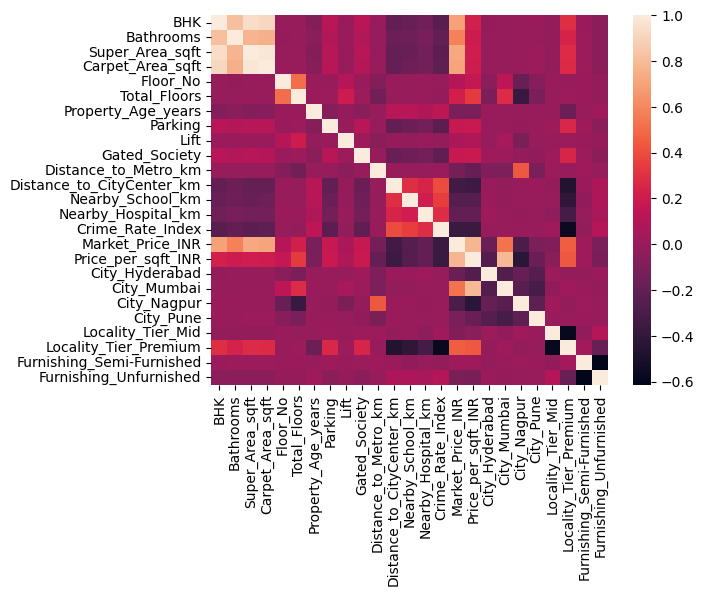

In [112]:
sns.heatmap(df2.corr(), annot=False)
plt.show()

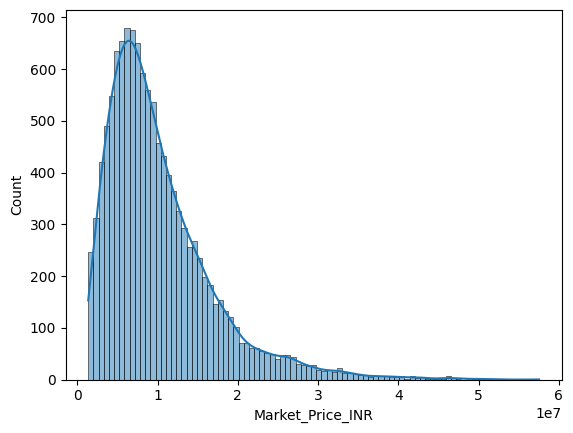

In [113]:
sns.histplot(df2["Market_Price_INR"], kde=True)
plt.show()

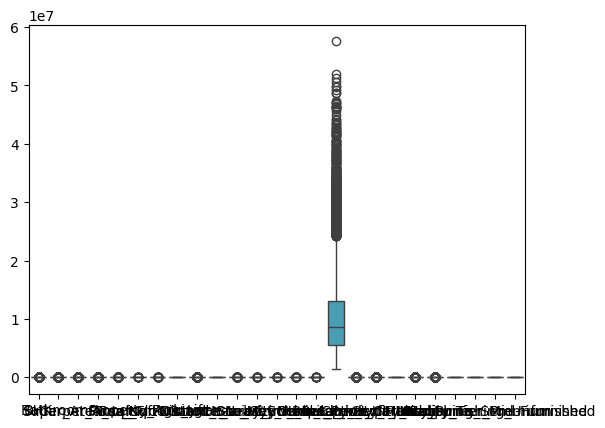

In [114]:
sns.boxplot(data=df2)
plt.show()

### 3) Feature Engineering / Target Transformation

In [115]:
# remove leakage feature
df2 = df2.drop("Price_per_sqft_INR", axis=1)

In [116]:
# log transform target variable
import numpy as np
df2["Market_Price_INR"] = np.log(df2["Market_Price_INR"])

In [117]:
# verify changes
df2.head()

,BHK,Bathrooms,Super_Area_sqft,Carpet_Area_sqft,Floor_No,Total_Floors,Property_Age_years,Parking,Lift,Gated_Society,...,Crime_Rate_Index,Market_Price_INR,City_Hyderabad,City_Mumbai,City_Nagpur,City_Pune,Locality_Tier_Mid,Locality_Tier_Premium,Furnishing_Semi-Furnished,Furnishing_Unfurnished
0,3,4,957.3,809.1,11,15,8,1,1,0,...,32.4,15.861454,True,False,False,False,True,False,True,False
1,2,3,883.3,711.7,13,16,13,1,1,0,...,66.3,15.568508,False,False,False,False,False,False,True,False
2,3,4,1331.5,1087.1,13,15,7,1,1,1,...,23.3,16.502549,False,False,False,True,False,True,False,True
3,3,4,997.6,801.0,7,19,10,1,1,1,...,18.8,16.764898,False,True,False,False,False,True,True,False
4,2,2,967.6,707.6,5,16,6,1,1,1,...,41.0,15.842661,False,False,False,True,True,False,False,True


### 4) Feature Selection / Extract Input and Output

In [118]:
# define input features and target variable

X2 = df2.drop("Market_Price_INR", axis=1)
y2 = df2["Market_Price_INR"]

In [119]:
# check shapes
X2.shape

(12000, 23)

In [120]:
y2.shape

(12000,)

### 5) Feature Scaling

In [121]:
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

In [122]:
X2_scaled.shape

(12000, 23)

### 6) Train Test Split

In [123]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_scaled, y2, test_size=0.2, random_state=42
)

In [124]:
X2_train.shape

(9600, 23)

In [125]:
X2_test.shape

(2400, 23)

### 7) Train the Models

#### a) Linear Regression

In [126]:
lr_model.fit(X2_train, y2_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### b) Random Forest

In [127]:
rf_model.fit(X2_train, y2_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

#### c) Gradient Boosting


In [128]:
gb_model.fit(X2_train, y2_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

#### d) XGBoost

In [129]:
xgb_model.fit(X2_train, y2_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

### 8) Evaluate the Models / Model Selection

In [130]:
# Predictions
lr_pred2 = lr_model.predict(X2_test)
rf_pred2 = rf_model.predict(X2_test)
gb_pred2 = gb_model.predict(X2_test)
xgb_pred2 = xgb_model.predict(X2_test)

In [131]:
# Linear Regression metrics
print("Linear Regression")
print("MAE:", mean_absolute_error(y2_test, lr_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y2_test, lr_pred2)))
print("R2:", r2_score(y2_test, lr_pred2))

Linear Regression
MAE: 0.10532083967347274
RMSE: 0.14072319305411501
R2: 0.9521080161385278


In [132]:
# Random Forest metrics
print("Random Forest")
print("MAE:", mean_absolute_error(y2_test, rf_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y2_test, rf_pred2)))
print("R2:", r2_score(y2_test, rf_pred2))

Random Forest
MAE: 0.06309458720061935
RMSE: 0.07977836269703846
R2: 0.9846077643462624


In [133]:
# Gradient Boosting metrics
print("Gradient Boosting")
print("MAE:", mean_absolute_error(y2_test, gb_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y2_test, gb_pred2)))
print("R2:", r2_score(y2_test, gb_pred2))

Gradient Boosting
MAE: 0.061668221555805085
RMSE: 0.07626907619661216
R2: 0.9859321270347998


In [134]:
# XGBoost metrics
print("XGBoost")
print("MAE:", mean_absolute_error(y2_test, xgb_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y2_test, xgb_pred2)))
print("R2:", r2_score(y2_test, xgb_pred2))

XGBoost
MAE: 0.05999413553718261
RMSE: 0.07362066419319979
R2: 0.9868921661340025


### Save/Download the model 

In [135]:
# save the final model
joblib.dump(xgb_model, "house_price_model.pkl")

['house_price_model.pkl']

In [136]:
# save the scaler (needed during prediction)
joblib.dump(scaler2, "scaler.pkl")

['scaler.pkl']